In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


# MNIST Data classification using KNN without PCA

In [52]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18423,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14639,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4460,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40964,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4147,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
df.shape

(42000, 785)

In [54]:
import matplotlib.pyplot as plt

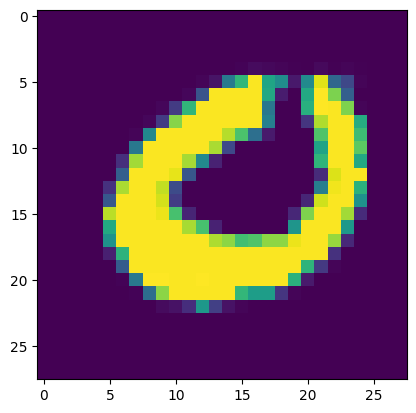

In [55]:
plt.imshow(df.iloc[6060,1:].values.reshape(28,28)) #it is zero

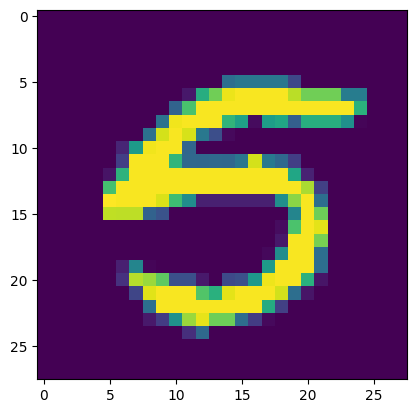

In [56]:
plt.imshow(df.iloc[14458,1:].values.reshape(28,28)) #it is five 

*we can see that each row in a datset represent a image of a digit*

In [57]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [58]:
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
y.head()

0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [62]:
X_train.shape

(33600, 784)

In [63]:
X_test.shape

(8400, 784)

In [64]:
y_train.shape,y_test.shape

((33600,), (8400,))

*y-train and y_test is a series not a dataframe as we can see its shape*

In [65]:
from sklearn.neighbors import KNeighborsClassifier

In [66]:
knn = KNeighborsClassifier()

In [67]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [68]:
y_pred = knn.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score

In [70]:
accuracy_score(y_pred,y_test)

0.9678571428571429

# MNIST Data classification using KNN with PCA

In [72]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()

In [75]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
X_train.shape

(33600, 784)

In [79]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = None)

In [80]:
X_train = pca.fit_transform(X_train)
X_test = pca.fit_transform(X_test)

In [81]:
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

**Now lets take the first 100 principal components and calculate accuracy score**

In [82]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
3772,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14104,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40380,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10413,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20712,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [85]:
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [86]:
pca = PCA(n_components = 100)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.fit_transform(X_test)

In [87]:
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [88]:
X_train_trf.shape,X_test_trf.shape

((33600, 100), (8400, 100))

In [89]:
#now fitting this to knn
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [91]:
y_ped = knn.predict(X_test_trf)

In [92]:
accuracy_score(y_pred,y_test)

0.10142857142857142

**Our score is very low, i dont know where i messed up!! let me restrat from scratch**

In [93]:
#importing dataset
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
37655,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38623,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2904,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15111,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
810,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [95]:
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
y.head()

0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

In [97]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [98]:
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [100]:
y_train.shape,y_test.shape

((33600,), (8400,))

In [102]:
#now mean centering 
from sklearn.preprocessing import StandardScaler
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [104]:
#now applying pca
from sklearn.decomposition import PCA
pca = PCA(n_components = 100)

In [105]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [107]:
X_train_trf.shape,X_test_trf.shape

((33600, 100), (8400, 100))

In [108]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [109]:
y_train.shape

(33600,)

In [110]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [111]:
y_pred = knn.predict(X_test_trf)

In [112]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9565476190476191

**we have reduced columns (dimensions) from 784 to 100 and still gets 95% score quite similar to score without pca,we can select and adjust n_components to get better score**

# PCA with 200pc

In [113]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [114]:
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [115]:
#now mean centering 
from sklearn.preprocessing import StandardScaler
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [116]:
#now applying pca
from sklearn.decomposition import PCA
pca = PCA(n_components = 200)

In [117]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [118]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [119]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [120]:
y_pred = knn.predict(X_test_trf)

In [121]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9458333333333333

**our score is decreased on taking 200 principal components**

In [122]:
#doing all this iteratively as 
for i in range(1,785):
    pca = PCA(n_components = i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf,y_train)
    y_pred = knn.predict(X_test_trf)
    print(accuracy_score(y_pred,y_test))
    

0.25833333333333336
0.3252380952380952
0.5133333333333333
0.6603571428571429
0.7335714285714285
0.8260714285714286
0.838452380952381
0.8711904761904762
0.8826190476190476
0.9069047619047619
0.9135714285714286
0.9179761904761905
0.9242857142857143
0.9314285714285714
0.9358333333333333
0.9342857142857143
0.935952380952381
0.9386904761904762
0.940595238095238
0.9425
0.9428571428571428
0.9432142857142857
0.9447619047619048
0.9457142857142857
0.9448809523809524
0.9454761904761905
0.945952380952381
0.9484523809523809
0.9488095238095238
0.9488095238095238
0.9484523809523809
0.9491666666666667
0.9483333333333334
0.9479761904761905
0.950952380952381
0.9495238095238095
0.9514285714285714
0.9519047619047619
0.9510714285714286
0.9520238095238095
0.9520238095238095
0.9523809523809523
0.9525
0.9521428571428572
0.9520238095238095
0.9519047619047619
0.9528571428571428
0.9530952380952381
0.9523809523809523
0.9516666666666667
0.9528571428571428
0.9522619047619048
0.9521428571428572
0.9520238095238095
0.

KeyboardInterrupt: 

In [123]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [124]:
X_train_trf

array([[ 6.36999057, -4.234809  ],
       [-1.27161335,  4.36662272],
       [ 2.92109307, -6.98927233],
       ...,
       [-4.20327706, -7.2437201 ],
       [ 5.78785682,  0.08201223],
       [-4.41421671, -5.85403877]])

In [126]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

see how we transform 784 th dimensional data to 2d using plotly taking 2 pricncipal components

In [127]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [128]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [129]:
pca.explained_variance_
# Eigen values

array([40.70345114, 29.11482263, 26.7373078 ])

In [130]:
pca.components_.shape
# Eigen vectors

(3, 784)

In [131]:
pca.explained_variance_ratio_

array([0.05757035, 0.04117957, 0.03781685])

# how to find optimal number of principal compnents?

In [132]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [133]:
pca.explained_variance_.shape

(784,)

In [134]:
pca.components_.shape

(784, 784)

In [135]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05757035, 0.09874992, 0.13656677, 0.16597812, 0.19156477,
       0.21383654, 0.23336804, 0.25103698, 0.26668581, 0.28097683,
       0.29456593, 0.30687003, 0.31824012, 0.32937336, 0.33991115,
       0.35008309, 0.35963026, 0.36897369, 0.37805362, 0.38703311,
       0.39540533, 0.40357731, 0.41134178, 0.41887809, 0.42623823,
       0.43328066, 0.44018952, 0.44689564, 0.45325968, 0.45947921,
       0.46560284, 0.47160873, 0.47744424, 0.48317361, 0.48884118,
       0.49433257, 0.49979353, 0.50510329, 0.51018314, 0.51513655,
       0.51995868, 0.52474004, 0.52938542, 0.53398233, 0.53850203,
       0.54299838, 0.5474447 , 0.55184067, 0.5562063 , 0.56047191,
       0.56468614, 0.56886342, 0.57293043, 0.57695345, 0.58092949,
       0.58487163, 0.5886712 , 0.59241059, 0.5961212 , 0.59980274,
       0.60335396, 0.60689942, 0.61037715, 0.61379906, 0.61721624,
       0.62060389, 0.6239528 , 0.62724133, 0.6304758 , 0.63364965,
       0.63680838, 0.63992436, 0.6429958 , 0.64606365, 0.64908

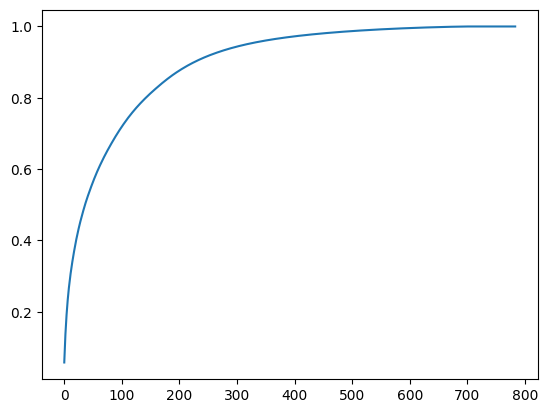

In [136]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

we can see that we can get 90% variance if we take n_components = 350-400 , in this way we can select optimal n_components